# Advanced Applications of AI/ML in Architecture

1. Generative Space Planning & Layout Topology: Instead of just drawing lines, AI allows architects to generate thousands of functional spatial layouts based on constraints (zoning laws, sunlight, circulation).

- The Technology: Graph Neural Networks (GNNs) and Generative Adversarial Networks (GANs).

- How it works: Rooms are treated as "nodes" and doors/corridors as "edges". The AI learns adjacency requirements (e.g., a bathroom must be next to a bedroom, a kitchen should not open directly into a mechanical room) and generates optimal floor plans.

- Training or running a model that morphs a bubble diagram into an optimized architectural floor plan.


2. Performance-Driven Structural Optimization: Moving beyond traditional CAD, ML allows for structural forms that mimic nature through mathematical optimization, saving massive amounts of material.

- The Technology: Topology Optimization combined with Surrogate Machine Learning Models.

- How it works: Traditional finite element analysis (FEA) takes hours to compute structural loads. By training an ML model on thousands of past structural tests, the AI can predict stress concentrations and remove unnecessary material in milliseconds.

- Generating complex, organic structural columns or 3D-printed concrete components optimized for minimal material use and maximum load capacity.

3. Predictive Environmental & Microclimate Simulations: Architects can use ML to design buildings that respond dynamically to climate change, daylighting, and wind patterns without waiting days for heavy engineering simulations.

- The Technology: Deep Learning Regression and Physics-Informed Neural Networks (PINNs).

- How it works: The AI analyzes the 3D massing of a building and instantly predicts its annual energy consumption, thermal comfort, or wind tunnel behavior at the pedestrian level.

- Predicting a building's solar radiation exposure based purely on its geometric shape and orientation coordinates.

## Predictive Solar Radiation (Form Follows Performance)

The below Python code simulates how a Surrogate Neural Network can predict solar heat gain on a building facade based on its geometry (height, width, orientation) and location.

This demonstrates how architects use AI to make instant, data-driven design decisions during early-stage massing.

Step 1: Simulated Facade Dataset

We will generate data for 500 building variations. The target is the "Solar Exposure Score" (which usually requires complex parametric tools like Grasshopper/Ladybug to compute).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Generate synthetic building massing data
np.random.seed(7)
n_buildings = 500

height = np.random.uniform(10, 100, n_buildings)       # Building height in meters
width = np.random.uniform(15, 60, n_buildings)         # Facade width
orientation = np.random.uniform(0, 360, n_buildings)    # Orientation in degrees (0 = North, 180 = South)
glazing_ratio = np.random.uniform(0.2, 0.8, n_buildings) # Percentage of glass on facade

# Simulated actual solar radiation (physics approximation for the dataset)
# South-facing (180 deg) with high glazing and high height gets maximum solar heat gain
solar_radiation = (np.sin(np.radians(orientation)) * -150) + (height * 2) + (glazing_ratio * 300) + np.random.normal(0, 25, n_buildings)
# Keep values positive
solar_radiation = np.clip(solar_radiation, 50, None)

# Create DataFrame
architectural_df = pd.DataFrame({
    'Height (m)': height,
    'Width (m)': width,
    'Orientation (deg)': orientation,
    'Glazing Ratio': glazing_ratio,
    'Solar Radiation (kWh/m²)': solar_radiation
})

architectural_df.head()

,Height (m),Width (m),Orientation (deg),Glazing Ratio,Solar Radiation (kWh/m²)
0,16.867746,58.407779,30.162913,0.253636,72.561749
1,80.192691,36.843468,189.415047,0.767414,431.454318
2,49.456831,36.541441,137.424459,0.355982,125.045860
3,75.111866,55.619867,294.586371,0.563677,484.807630
4,98.019056,15.715969,102.229945,0.482352,142.357855


### Step 2: Training a Surrogate Neural Network

Instead of running a 10-minute physics simulation every time an architect changes a wall, this Neural Network will predict the solar impact instantly.

In [ ]:
# Features and Target
X = architectural_df[['Height (m)', 'Width (m)', 'Orientation (deg)', 'Glazing Ratio']]
y = architectural_df['Solar Radiation (kWh/m²)']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features for the Neural Network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Multi-Layer Perceptron (Neural Network) Regressor
ai_simulator = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=42)
ai_simulator.fit(X_train_scaled, y_train)

# Test the AI's accuracy
predictions = ai_simulator.predict(X_test_scaled)
print(f"AI Simulator trained successfully.")

AI Simulator trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


### Step 3: Visualizing the AI Simulation vs. Reality

Show your students how accurately the AI can map and predict architectural physics.



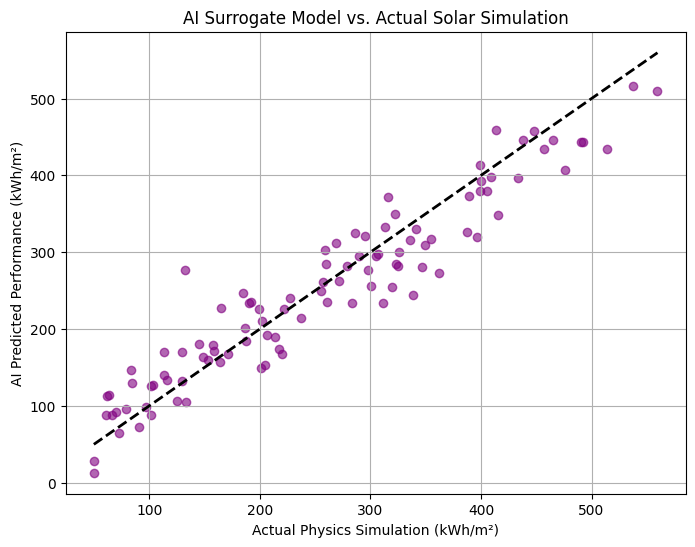

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('AI Surrogate Model vs. Actual Solar Simulation')
plt.xlabel('Actual Physics Simulation (kWh/m²)')
plt.ylabel('AI Predicted Performance (kWh/m²)')
plt.grid(True)
plt.show()

With a trained model like this running inside a CAD program (like Rhino or Revit), an architect can warp a building's shape and see its carbon footprint or solar heat gain recalculate live as they push and pull the geometry.

The Black Box of Physics: What happens if the AI learns a physics pattern incorrectly? Should architects trust neural network approximations over traditional calculation codes when signing off on building safety or sustainability ratings?